In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPRegressor, MLPClassifier

# Multilayer Perceptron in scikit-learn

scikit-learn provides two main classes for feed-forward neural networks based on the multilayer perceptron (MLP):

- `MLPRegressor` for **regression**
- `MLPClassifier` for **classification**

Both share a very similar structure and many hyperparameters. Broadly, these hyperparameters control the network architecture, the loss and output behavior, the hidden-layer activation functions, the optimization strategy, and the training dynamics.


### 1. Architecture
These define the shape and capacity of the network.

- `hidden_layer_sizes` *(default: `(100,)`)*: number of neurons in each hidden layer.

### 2. Loss and output behavior
These specify the training objective. In practice, this part differs the most between regression and classification.

- `loss` *(for `MLPRegressor`, default: `'squared_error'`)*: loss used for regression. Options include `'squared_error'` and `'poisson'`, where `'poisson'` requires $y \ge 0$.

For `MLPClassifier`, the classification loss is handled internally according to the task and output setup.

### 3. Hidden-layer activation functions
These control the nonlinearity used in hidden layers.

- `activation` *(`'identity'`, `'logistic'`, `'tanh'`, `'relu'`; default: `'relu'`)*: activation function for hidden layers.

### 4. Optimization
These determine how weights are updated during training.

- `solver` *(`'lbfgs'`, `'sgd'`, `'adam'`; default: `'adam'`)*: optimization algorithm.
- `learning_rate` *(`'constant'`, `'invscaling'`, `'adaptive'`; default: `'constant'`)*: learning-rate schedule, only for `solver='sgd'`.
- `learning_rate_init` *(default: `0.001`)*: initial learning rate.
- `power_t` *(default: `0.5`)*: exponent for inverse scaling, only with `solver='sgd'` and `learning_rate='invscaling'`.
- `momentum` *(default: `0.9`)*: momentum term, only for `solver='sgd'`.
- `nesterovs_momentum` *(default: `True`)*: whether to use Nesterov momentum, only for `solver='sgd'`.
- `beta_1` *(default: `0.9`)*: exponential decay rate for first-moment estimates in Adam.
- `beta_2` *(default: `0.999`)*: exponential decay rate for second-moment estimates in Adam.
- `epsilon` *(default: `1e-8`)*: numerical stability constant for Adam.
- `max_fun` *(default: `15000`)*: maximum number of function calls, only for `solver='lbfgs'`.

### 5. Regularization
These help control overfitting.

- `alpha` *(default: `0.0001`)*: L2 regularization strength.

### 6. Batch size and training dynamics
These control how training proceeds over the dataset.

- `batch_size` *(default: `'auto'`)*: minibatch size for stochastic solvers.
- `max_iter` *(default: `200`)*: maximum number of iterations or epochs.
- `tol` *(default: `1e-4`)*: convergence tolerance.
- `early_stopping` *(default: `False`)*: whether to stop training when validation performance stops improving.
- `validation_fraction` *(default: `0.1`)*: fraction of training data used for validation when `early_stopping=True`.
- `n_iter_no_change` *(default: `10`)*: number of epochs with no sufficient improvement before stopping.


## Dataset

The dataset was generated from a deep learning model trained on the Obesity or CVD risk dataset. 
https://www.kaggle.com/datasets/aravindpcoder/obesity-or-cvd-risk-classifyregressorcluster

The data consist of the estimation of obesity levels in people from the countries of Mexico, Peru and Colombia, with ages between 14 and 61 and diverse eating habits and physical condition , data was collected using a web platform with a survey where anonymous users answered each question, then the information was processed obtaining 17 attributes and 2111 records.
The attributes related with eating habits are: Frequent consumption of high caloric food (FAVC), Frequency of consumption of vegetables (FCVC), Number of main meals (NCP), Consumption of food between meals (CAEC), Consumption of water daily (CH20), and Consumption of alcohol (CALC). The attributes related with the physical condition are: Calories consumption monitoring (SCC), Physical activity frequency (FAF), Time using technology devices (TUE), Transportation used (MTRANS)
variables obtained :
Gender, Age, Height and Weight.

NObesity values are:

- Underweight Less than 18.5
- Normal 18.5 to 24.9
- Overweight 25.0 to 29.9
- Obesity I 30.0 to 34.9
- Obesity II 35.0 to 39.9
- Obesity III Higher than 40

In [2]:
df = pd.read_csv("./Data/playground-series-s4e2/train.csv")
df

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,20753,Male,25.137087,1.766626,114.187096,yes,yes,2.919584,3.000000,Sometimes,no,2.151809,no,1.330519,0.196680,Sometimes,Public_Transportation,Obesity_Type_II
20754,20754,Male,18.000000,1.710000,50.000000,no,yes,3.000000,4.000000,Frequently,no,1.000000,no,2.000000,1.000000,Sometimes,Public_Transportation,Insufficient_Weight
20755,20755,Male,20.101026,1.819557,105.580491,yes,yes,2.407817,3.000000,Sometimes,no,2.000000,no,1.158040,1.198439,no,Public_Transportation,Obesity_Type_II
20756,20756,Male,33.852953,1.700000,83.520113,yes,yes,2.671238,1.971472,Sometimes,no,2.144838,no,0.000000,0.973834,no,Automobile,Overweight_Level_II


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

In [4]:
df.nunique()

id                                20758
Gender                                2
Age                                1703
Height                             1833
Weight                             1979
family_history_with_overweight        2
FAVC                                  2
FCVC                                934
NCP                                 689
CAEC                                  4
SMOKE                                 2
CH2O                               1506
SCC                                   2
FAF                                1360
TUE                                1297
CALC                                  3
MTRANS                                5
NObeyesdad                            7
dtype: int64

In [5]:
# Split the data into features and target variable

target = "NObeyesdad"
y = df[target]
X = df.drop(columns=[target, "id"])

In [6]:
# Convert categorical variables to numeric using one-hot encoding

X[X.select_dtypes('object').columns] = X.select_dtypes('object').apply(pd.Categorical)
X = pd.get_dummies(X, drop_first=True).astype(float)

In [7]:
# Convert labels to numeric using LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)
np.unique(y), le.classes_

(array([0, 1, 2, 3, 4, 5, 6]),
 array(['Insufficient_Weight', 'Normal_Weight', 'Obesity_Type_I',
        'Obesity_Type_II', 'Obesity_Type_III', 'Overweight_Level_I',
        'Overweight_Level_II'], dtype=object))

In [8]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((16606, 22), (4152, 22), (16606,), (4152,))

### Dummy Classifier

In [9]:
from sklearn.dummy import DummyClassifier

model = DummyClassifier(strategy="most_frequent")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.06282803118308164

### Simple Perceptron
A neural network with no hidden layers. It's actually better than the traditional Simple Perceptron, because we use a better learning rule, e.g., SGD. 

In [10]:
model = MLPClassifier(
    hidden_layer_sizes=tuple(),
    solver="sgd",
    alpha=0,
    random_state=42,
    batch_size=1,
    shuffle=False,
    momentum=0,
    max_iter=50
)
model.fit(X_train, y_train)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(alpha=0, batch_size=1, hidden_layer_sizes=(), max_iter=50,
              momentum=0, random_state=42, shuffle=False, solver='sgd')

In [11]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.5056397472570227

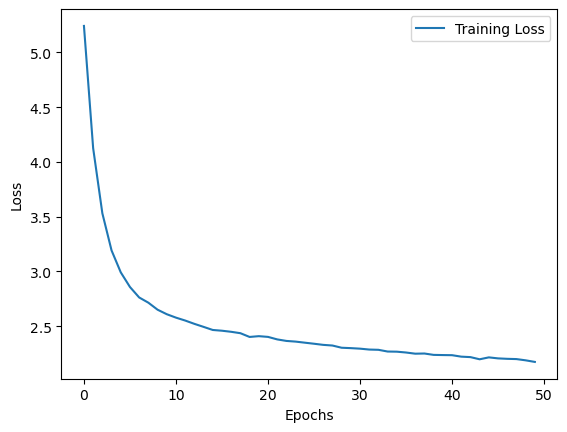

In [12]:
plt.plot(model.loss_curve_, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [13]:
len(model.coefs_)

1

In [14]:
model.coefs_[0].shape

(22, 7)

### MLP
Let's try to build a better-performing neural network

In [15]:
model = MLPClassifier(
    hidden_layer_sizes=(32,),  # one hidden layer with 32 neurons
    solver="sgd",  # use Adam optimizer
    alpha=0.001,  # L2 regularization term
    max_iter=200,  # maximum number of iterations
    random_state=42,  # for reproducibility
    batch_size=32,  # size of mini-batches for stochastic optimization
    shuffle=True,  # whether to shuffle samples in each iteration
)

In [16]:
model.fit(X_train, y_train)

/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(alpha=0.001, batch_size=32, hidden_layer_sizes=(32,),
              random_state=42, solver='sgd')

In [17]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.7083581016983255

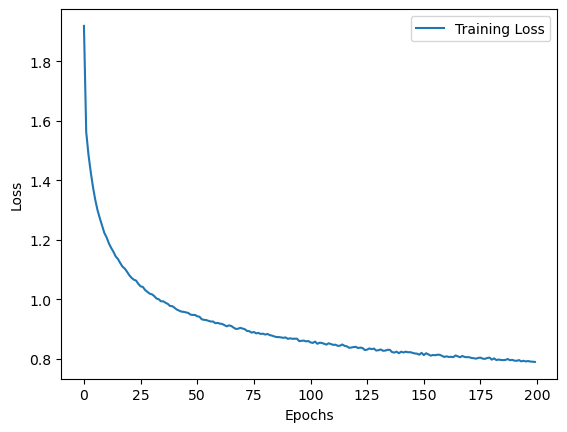

In [18]:
plt.plot(model.loss_curve_, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

#### Early stopping

In [19]:
model =  MLPClassifier(
    hidden_layer_sizes=(32,),  
    solver="adam",  
    alpha=0.001, 
    max_iter=200,  
    random_state=42,  
    batch_size=32,  
    shuffle=True,
    
    # parameters for early stopping
    early_stopping=True,  # whether to use early stopping to terminate training when validation score is not improving
    n_iter_no_change=10,  # maximum number of epochs to not meet tol improvement
    validation_fraction=0.1,  # proportion of training data to set aside as validation set for early stopping
)

In [20]:
model.fit(X_train, y_train)

MLPClassifier(alpha=0.001, batch_size=32, early_stopping=True,
              hidden_layer_sizes=(32,), random_state=42)

In [21]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.8488868013898571

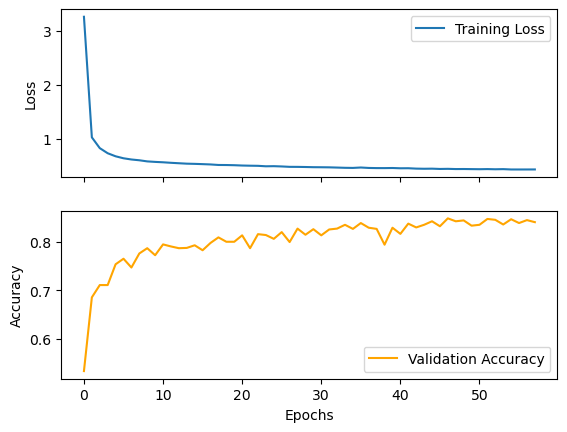

In [22]:
fig, axs = plt.subplots(2, 1, sharex=True)

axs[0].plot(model.loss_curve_, label="Training Loss")
axs[1].plot(model.validation_scores_, label="Validation Accuracy", color="orange")
plt.xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[1].set_ylabel("Accuracy")
axs[0].legend()
axs[1].legend()
plt.show()

#### Random Search

In [23]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform

param_dist = {
    "hidden_layer_sizes": [
        (16,), (32,), (64,), (128,),  # single hidden layer with varying neurons
        (16, 16), (32, 32), (64, 64), (128, 128)  # two hidden layers with varying neurons
    ],
    "alpha": loguniform(1e-4, 1e-1),  # samples continuously from log scale
    "solver": ["sgd", "adam"],
    "learning_rate_init": [1e-4, 1e-3, 1e-2],
}

base_model = MLPClassifier(
    solver="adam",
    max_iter=200,
    random_state=42,
    shuffle=True,
    validation_fraction=0.1,
    early_stopping=True,
    n_iter_no_change=10,
)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=30,           # number of random combinations to try
    scoring="f1_weighted",  # evaluation metric
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

In [24]:
%%time
random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/francesco/miniforge3/envs/timeseries_dl/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached 

Best params: {'alpha': 0.0010025956902289571, 'hidden_layer_sizes': (128, 128), 'learning_rate_init': 0.01, 'solver': 'adam'}
Best CV score: 0.8486040544497131
CPU times: user 1min 26s, sys: 2.57 s, total: 1min 29s
Wall time: 49 s


In [25]:
y_pred = model.predict(X_test)
f1_score(y_test, y_pred, average="weighted")

0.8488868013898571

# Exercise
Build a neural network to predict the Age as a target, evaluate it using the MAE

In [26]:
target = "Age"
y = df[target]
X = df.drop(columns=[target, "id"])

In [27]:
# Convert categorical variables to numeric using one-hot encoding

X[X.select_dtypes('object').columns] = X.select_dtypes('object').apply(pd.Categorical)
X = pd.get_dummies(X, drop_first=True).astype(float)

In [28]:
# Split the data into training and testing sets

In [29]:
# (Optional) test a dummy model to set a baseline performance

In [30]:
# build and evaluate the MLP model